In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Datensatz laden und Exploration

In [ ]:
df = pd.read_csv("movie_metadata.csv", sep=",")

In [ ]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [ ]:
df.shape

(5043, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [ ]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


In [ ]:
df.isnull().sum().sort_values(ascending=False)

gross                        884
budget                       492
aspect_ratio                 329
content_rating               303
plot_keywords                153
title_year                   108
director_facebook_likes      104
director_name                104
num_critic_for_reviews        50
actor_3_facebook_likes        23
actor_3_name                  23
num_user_for_reviews          21
color                         19
duration                      15
language                      14
actor_2_facebook_likes        13
actor_2_name                  13
facenumber_in_poster          13
actor_1_name                   7
actor_1_facebook_likes         7
country                        5
genres                         0
movie_title                    0
cast_total_facebook_likes      0
movie_imdb_link                0
num_voted_users                0
imdb_score                     0
movie_facebook_likes           0
dtype: int64

In [ ]:
# Korrelationen
df.corr(numeric_only=True)['imdb_score'].sort_values()

title_year                  -0.209167
facenumber_in_poster        -0.062958
budget                       0.030688
actor_3_facebook_likes       0.052633
aspect_ratio                 0.059445
actor_1_facebook_likes       0.076099
actor_2_facebook_likes       0.083808
cast_total_facebook_likes    0.085787
director_facebook_likes      0.170802
gross                        0.198021
movie_facebook_likes         0.247049
duration                     0.261662
num_user_for_reviews         0.292475
num_critic_for_reviews       0.305303
num_voted_users              0.410965
imdb_score                   1.000000
Name: imdb_score, dtype: float64

<Axes: >

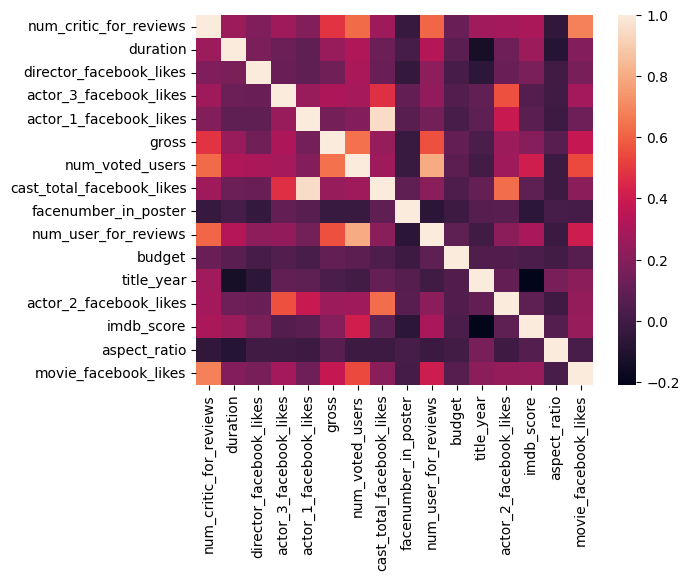

In [ ]:
# Heatmap Korrelationen
sns.heatmap(df.corr(numeric_only=True))

In [ ]:
# Kategorien zählen
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(col, df[col].nunique())

color 2
director_name 2398
actor_2_name 3032
genres 914
actor_1_name 2097
movie_title 4917
actor_3_name 3521
plot_keywords 4760
movie_imdb_link 4919
language 46
country 65
content_rating 18


movie_title, plot_keywords, movie_imdb_link, actor_3_name droppen, evtl. auch actor_2_name

# Data Cleaning

In [ ]:
df = df.drop_duplicates()

print("Neue Shape:", df.shape)

## Nicht benötigte Features entfernen

In [ ]:
df = df.drop(columns=[
    "movie_title",
    "movie_imdb_link",
    "plot_keywords",
    "actor_1_facebook_likes",
    "actor_2_facebook_likes",
    "actor_3_facebook_likes",
    "facenumber_in_poster",
    "num_user_for_reviews",
    "director_facebook_likes",
    "num_critic_for_reviews"
])

## Genre vereinfachen

Die Spalte "genres" enthält mehrere Genres pro Film.
Für dieses Projekt wird nur das erste Genre verwendet.

In [ ]:
df["main_genre"] = df["genres"].apply(
    lambda x: x.split("|")[0] if pd.notna(x) else x
)

df = df.drop(columns=["genres"])



## X und y definieren

In [ ]:
# Zielvariable
y = df["imdb_score"].copy()

# Features
X = df.drop("imdb_score", axis=1)

## Train / Validation / Test Split

In [ ]:
#Test
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42
)

# Fehlende Werte behandeln

Numerische Features -> Median

Kategorische Features -> Modus

In [ ]:
num_cols = [
    "duration",
    "gross",
    "budget",
    "aspect_ratio",
    "title_year",
    "movie_facebook_likes",
    "cast_total_facebook_likes"
]

cat_cols = [
    "color",
    "director_name",
    "actor_2_name",
    "main_genre",
    "actor_1_name",
    "actor_3_name",
    "language",
    "country",
    "content_rating",
]



## Median auf Train berechnen

In [ ]:
for col in num_cols:
    
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_val[col] = X_val[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

## Mode auf Train berechnen

In [ ]:
for col in cat_cols:

    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)
    X_val[col] = X_val[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

# Log Transform

In [ ]:
for dataset in [X_train, X_val, X_test]:

    dataset["budget"] = np.log1p(dataset["budget"])
    dataset["movie_facebook_likes"] = np.log1p(dataset["movie_facebook_likes"])
    dataset["cast_total_facebook_likes"] = np.log1p(dataset["cast_total_facebook_likes"])

### Check NaN again

In [ ]:
print("Train")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("Val")
print(X_val.isnull().sum()[X_val.isnull().sum() > 0])

print("Test")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])


# One-Hot-Encoding

In [ ]:
X_train = pd.get_dummies(
    X_train,
    columns=["color", "language", "main_genre", "country", "content_rating", "director_name", "actor_1_name", "actor_2_name", "actor_3_name",],
    drop_first=True
)

X_val = pd.get_dummies(
    X_val,
    columns=["color", "language", "main_genre", "country", "content_rating", "director_name", "actor_1_name", "actor_2_name", "actor_3_name",],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=["color", "language", "main_genre", "country", "content_rating", "director_name", "actor_1_name", "actor_2_name", "actor_3_name",],
    drop_first=True
)

## Reindex

In [ ]:
X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Scaling 

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

## Baseline

In [ ]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

pred_baseline = baseline.predict(X_val)

print(
    "Baseline MSE:",
    mean_squared_error(y_val, pred_baseline)
)

## Linear Regression

In [ ]:
model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

# Validation

In [ ]:
y_val_pred = model.predict(X_val_scaled)

print(
    "Validation MSE:",
    mean_squared_error(y_val, y_val_pred)
)

print(
    "Validation MAE:",
    mean_absolute_error(y_val, y_val_pred)
)

print(
    "Validation R²:",
    r2_score(y_val, y_val_pred)
)

# Test

In [ ]:
y_test_pred = model.predict(X_test_scaled)

print(
    "Test MSE:",
    mean_squared_error(y_test, y_test_pred)
)

print(
    "Test MAE:",
    mean_absolute_error(y_test, y_test_pred)
)

print(
    "Test R²:",
    r2_score(y_test, y_test_pred)
)